# Lock-free shared time for Flux Fiction

## Design, microbenchmark, and full Fluxion/DFTracer validation

This notebook documents the `libfaketime` shared-clock optimization
and the evidence behind it. The short version is:

- a realtime read falls from **22,733 ns** with a no-cache timestamp file
  to **52.9 ns** with the shared page (**429.5x faster**);
- the rabbit300 annotation workload falls from **79.0 s** in fork-legacy
  mode to **40.5 s** in shared mode (**1.95x faster**);
- shared mode is statistically indistinguishable from running without
  `libfaketime` (42-43 s), while keeping Fluxion events on the
  simulated timeline;
- with Fluxion annotations compiled out, legacy, shared, and no-faketime
  all finish within a four-second band.

The notebook reads the preserved raw CSV files. No benchmark is rerun here.

In [1]:
from pathlib import Path
import hashlib
import subprocess

import numpy as np
import pandas as pd
from IPython.display import display
from plotnine import (
    aes, element_blank, element_text, geom_boxplot, geom_jitter,
    geom_point, geom_text, ggplot, labs, scale_color_manual,
    scale_fill_manual, scale_x_continuous, scale_y_log10,
    theme, theme_minimal,
)

workspace_candidates = [
    Path("/g/g14/ashworth12/workspace/ff-podman"),
    Path("/usr/WS1/ashworth12/ff-podman"),
]
WS = next(path for path in workspace_candidates if path.exists())
FT = WS / "libfaketime-shared-clock"
FF = WS / "flux-fiction-shared-clock"
UT = WS / "unified-trace"

MICRO_CSV = FT / "benchmarks/shared-clock/raw_results.csv"
MICRO_METADATA = FT / "benchmarks/shared-clock/machine_metadata.txt"
SMOKE_CSV = FF / "benchmarks/shared-clock/e2e_results.csv"
FULL_CSV = UT / "ab-faketime/results_ok.csv"
for path in (MICRO_CSV, MICRO_METADATA, SMOKE_CSV, FULL_CSV):
    assert path.exists(), path

micro = pd.read_csv(MICRO_CSV)
smoke = pd.read_csv(SMOKE_CSV)
full = pd.read_csv(FULL_CSV)

COLORS = {
    "Native": "#4C78A8",
    "No libfaketime": "#4C78A8",
    "Shared page": "#2A9D8F",
    "Fork legacy": "#F4A261",
    "Distro legacy": "#E76F51",
    "Legacy timestamp file": "#E76F51",
}

def large_theme(width=10, height=5.8):
    return (
        theme_minimal(base_size=16)
        + theme(
            figure_size=(width, height),
            plot_title=element_text(size=21, weight="bold"),
            plot_subtitle=element_text(size=15),
            axis_title=element_text(size=16),
            axis_text=element_text(size=14),
            legend_title=element_text(size=14),
            legend_text=element_text(size=13),
            plot_caption=element_text(size=11, color="#555555"),
            panel_grid_minor=element_blank(),
        )
    )

print(f"Workspace: {WS}")
print(f"Microbenchmark rows: {len(micro)}; successful full runs: {len(full)}")

Workspace: /g/g14/ashworth12/workspace/ff-podman
Microbenchmark rows: 27; successful full runs: 34


## 1. Provenance

The optimization is commit `2b95f2f` in
`libfaketime-shared-clock`. The microbenchmark was collected while
that change was still an uncommitted working-tree diff over
`d79bf0f`; the final commit records the tested implementation and
benchmark assets. The full run uses the Flux Fiction integration commit
`56653ef` and the annotated Fluxion tree at `d21ef77`.

In [2]:
def git_revision(path):
    return subprocess.check_output(
        ["git", "-C", str(path), "rev-parse", "HEAD"], text=True
    ).strip()

metadata = {}
for line in MICRO_METADATA.read_text().splitlines():
    if "=" in line:
        key, value = line.split("=", 1)
        metadata[key] = value

provenance = pd.DataFrame([
    ("libfaketime optimization", git_revision(FT), "feature/shared-memory-clock"),
    ("Flux Fiction integration", git_revision(FF), "feature/libfaketime-shared-clock"),
    ("Fluxion annotations", git_revision(WS / "flux-sched-dft"), "dftracer-annotations"),
    ("microbenchmark host", metadata["hostname"], metadata["cpu_model"]),
    ("microbenchmark compiler", metadata["compiler"], metadata["compiler_flags"]),
    ("distro comparison", "libfaketime 0.9.10-2.1", "Ubuntu/Debian package"),
], columns=["artifact", "revision / value", "branch / detail"])
display(provenance)

,artifact,revision / value,branch / detail
0,libfaketime optimization,2b95f2f0f0ac1b4f09699bce63afa9c497d69035,feature/shared-memory-clock
1,Flux Fiction integration,56653ef640bb4d2d0ae17e1881afe2b30f4ec375,feature/libfaketime-shared-clock
2,Fluxion annotations,d21ef77a555f593bde5a6f26ce2ef3a480c599e8,dftracer-annotations
3,microbenchmark host,tuolumne2151,AMD Instinct MI300A Accelerator
4,microbenchmark compiler,gcc (GCC) 8.5.0 20210514 (Red Hat 8.5.0-28),-O2 -std=gnu11 -Wall -Wextra -Werror
5,distro comparison,libfaketime 0.9.10-2.1,Ubuntu/Debian package


## 2. What was optimized

Flux Fiction repeatedly advances simulated wall time. In compatible legacy
mode it writes a timestamp file and sets `FAKETIME_NO_CACHE=1`,
forcing every intercepted realtime read to reopen, read, and parse the
file. DFTracer makes this pathological: annotation level 5 emits 2.57
million Fluxion events, and every event construction/destruction path
reads time.

| Operation | Legacy timestamp file | Shared-clock mode |
|---|---|---|
| Controller update | atomic temporary-file write + rename | `faketime_set_realtime_ns(int64_t)` |
| Reader hot path | open/read/parse/close, plus legacy mode logic | resolved real clock call + atomic loads + integer arithmetic |
| Cross-process propagation | every process sees the same file | named POSIX shared page; inherited across `fork`, reattached after `exec` |
| Synchronization | file operations and MT-library locking | versioned sequence counter; no process-shared lock on reads |
| Clock scope | normal libfaketime behavior | realtime family only; monotonic clocks remain real |

### Shared-page ABI and publication protocol

The mapped page is versioned with a magic value and contains atomic fields
for a sequence number, the real and fake realtime bases, a coarse-clock
base, and flags. The payload fields are atomic, not merely protected by the
sequence, so readers in the writer process do not create a C data race.

Conceptually, a read computes:

```text
fake_now = fake_base + (real_now - real_base)
```

A reader samples an even sequence, loads the bases, obtains real realtime
through the already-resolved libc function, and accepts the sample only if
the sequence is unchanged. A writer claims an odd sequence with
compare/exchange, publishes a fresh real/fake base pair, then releases an
even sequence. Multiple writers are serialized without a semaphore.

The mode is explicitly opt-in with `FAKETIME_SHARED_CLOCK=1`. The
creator publishes the POSIX object name in
`FAKETIME_SHARED_CLOCK_SHM`; executed descendants attach to that
identity. The public API is:

```c
int faketime_shared_clock_available(void);
int faketime_set_realtime_ns(int64_t target_ns);
```

It covers `CLOCK_REALTIME`, `CLOCK_REALTIME_COARSE`,
`gettimeofday()`, and `time()`. The low-level setter accepts
backward targets; Flux Fiction is responsible for enforcing monotonic
simulated progress. Shared mode requires POSIX shared memory and lock-free
64-bit atomics.

## 3. C microbenchmark

`clock_benchmark.c` performs 100,000 warm-up calls followed by
1,000,000 timed `clock_gettime(CLOCK_REALTIME)` calls. The
measurement clock is a direct
`SYS_clock_gettime(CLOCK_MONOTONIC_RAW)` syscall, so preload
interposition cannot fake elapsed time. Nine independent repetitions used
randomized mode order and CPU pinning.

Legacy updates use an atomic temporary file plus rename on
`/dev/shm`; shared updates call the cached C API. Update timing
averages 1,000 consecutive updates and excludes one-time symbol lookup and
page attachment.

In [3]:
micro_labels = {
    "native": "Native",
    "legacy": "Legacy timestamp file",
    "shared": "Shared page",
}

def distribution(values):
    values = pd.Series(values, dtype=float)
    return {
        "n": len(values),
        "median_ns": values.median(),
        "iqr_ns": values.quantile(0.75) - values.quantile(0.25),
        "min_ns": values.min(),
        "max_ns": values.max(),
    }

read_rows = []
for mode in ("native", "legacy", "shared"):
    row = {
        "mode": micro_labels[mode],
        **distribution(micro.loc[micro["mode"] == mode, "latency_ns"]),
    }
    read_rows.append(row)
read_summary = pd.DataFrame(read_rows)
native_median = read_summary.loc[
    read_summary["mode"] == "Native", "median_ns"
].iloc[0]
read_summary["relative_to_native"] = (
    read_summary["median_ns"] / native_median
)

update_rows = []
for mode in ("legacy", "shared"):
    values = micro.loc[micro["mode"] == mode, "update_ns"] / 1_000
    stats = distribution(values)
    update_rows.append({
        "mode": micro_labels[mode],
        "n": stats["n"],
        "median_us": stats["median_ns"],
        "iqr_us": stats["iqr_ns"],
        "min_us": stats["min_ns"],
        "max_us": stats["max_ns"],
    })
update_summary = pd.DataFrame(update_rows)

display(read_summary.round({
    "median_ns": 2, "iqr_ns": 2, "min_ns": 2,
    "max_ns": 2, "relative_to_native": 2,
}))
display(update_summary.round(3))

legacy_read = read_summary.loc[
    read_summary["mode"] == "Legacy timestamp file", "median_ns"
].iloc[0]
shared_read = read_summary.loc[
    read_summary["mode"] == "Shared page", "median_ns"
].iloc[0]
legacy_update = update_summary.loc[
    update_summary["mode"] == "Legacy timestamp file", "median_us"
].iloc[0]
shared_update = update_summary.loc[
    update_summary["mode"] == "Shared page", "median_us"
].iloc[0]
print(f"Read speedup:   {legacy_read / shared_read:.2f}x")
print(f"Update speedup: {legacy_update / shared_update:.2f}x")
print(f"Shared/native read cost: {shared_read / native_median:.2f}x")

,mode,n,median_ns,iqr_ns,min_ns,max_ns,relative_to_native
0,Native,9,23.76,0.22,23.55,24.13,1.00
1,Legacy timestamp file,9,22733.17,276.70,22528.98,23068.33,956.72
2,Shared page,9,52.92,1.02,51.60,53.54,2.23


,mode,n,median_us,iqr_us,min_us,max_us
0,Legacy timestamp file,9,57.776,0.712,55.926,59.619
1,Shared page,9,0.129,0.016,0.099,0.152


Read speedup:   429.54x
Update speedup: 447.88x
Shared/native read cost: 2.23x


### Realtime-read latency

Each point is one million-call repetition; the box summarizes the same
nine points. The logarithmic axis is necessary because the timestamp-file
path is nearly three orders of magnitude slower.

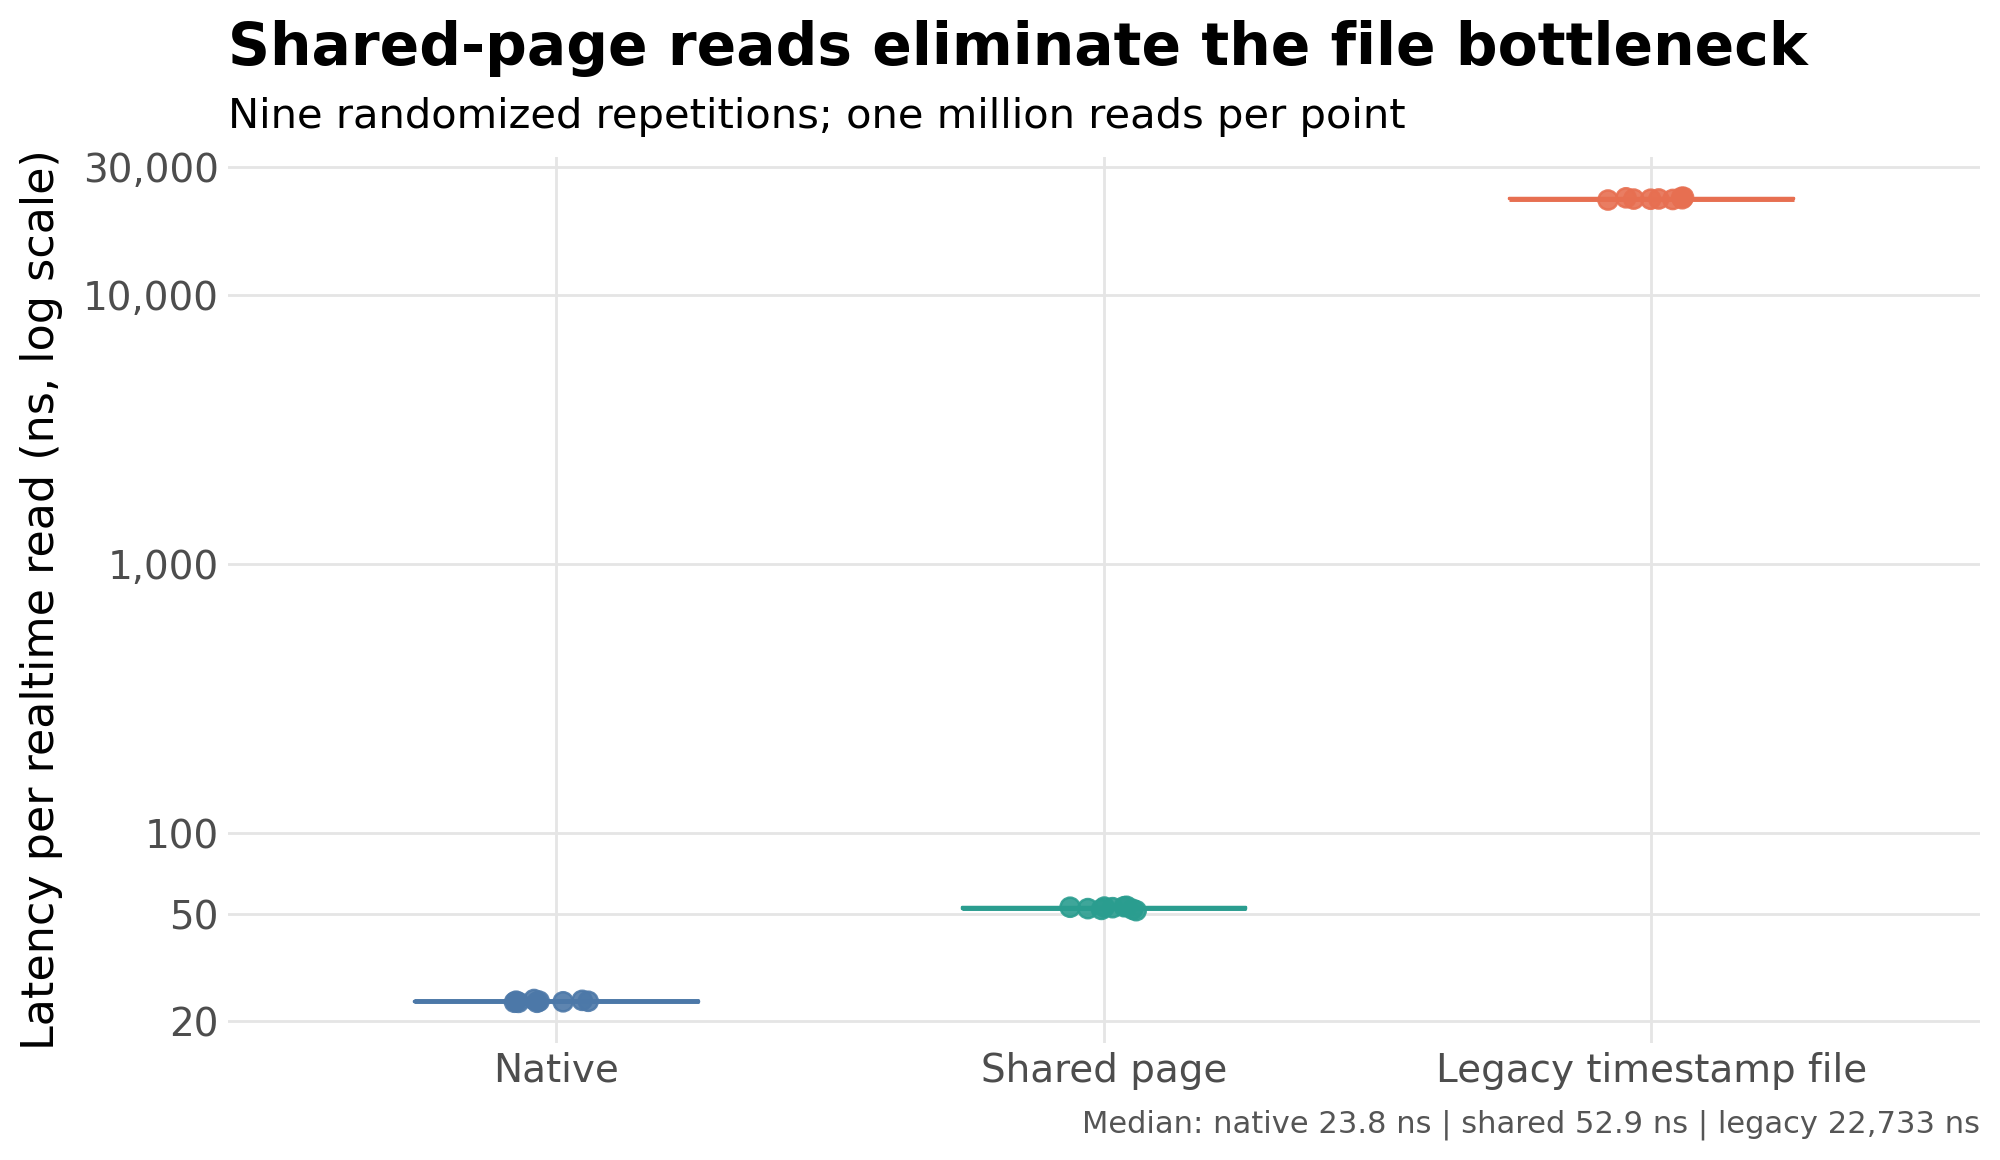

In [ ]:
read_plot = micro.copy()
read_plot["clock"] = read_plot["mode"].map(micro_labels)
read_order = ["Native", "Shared page", "Legacy timestamp file"]
read_plot["clock"] = pd.Categorical(
    read_plot["clock"], categories=read_order, ordered=True
)
read_colors = {label: COLORS[label] for label in read_order}

p_read = (
    ggplot(read_plot, aes("clock", "latency_ns", color="clock"))
    + geom_boxplot(
        aes(fill="clock"), width=0.52, alpha=0.25, outlier_alpha=0
    )
    + geom_jitter(width=0.08, height=0, size=3.4, alpha=0.9)
    + scale_color_manual(values=read_colors)
    + scale_fill_manual(values=read_colors)
    + scale_y_log10(
        breaks=[20, 50, 100, 1_000, 10_000, 30_000],
        labels=["20", "50", "100", "1,000", "10,000", "30,000"],
    )
    + labs(
        title="Read performance across faketime modes",
        subtitle="Nine randomized repetitions; one million reads per point",
        x="",
        y="Latency per realtime read (ns, log scale)",
        caption=(
            "Median: native 23.8 ns | shared 52.9 ns | "
            "legacy 22,733 ns"
        ),
    )
    + large_theme()
    + theme(legend_position="none")
)
p_read

### Clock-update latency

Publishing to an already mapped page avoids file creation, formatting,
rename, and later reparsing.

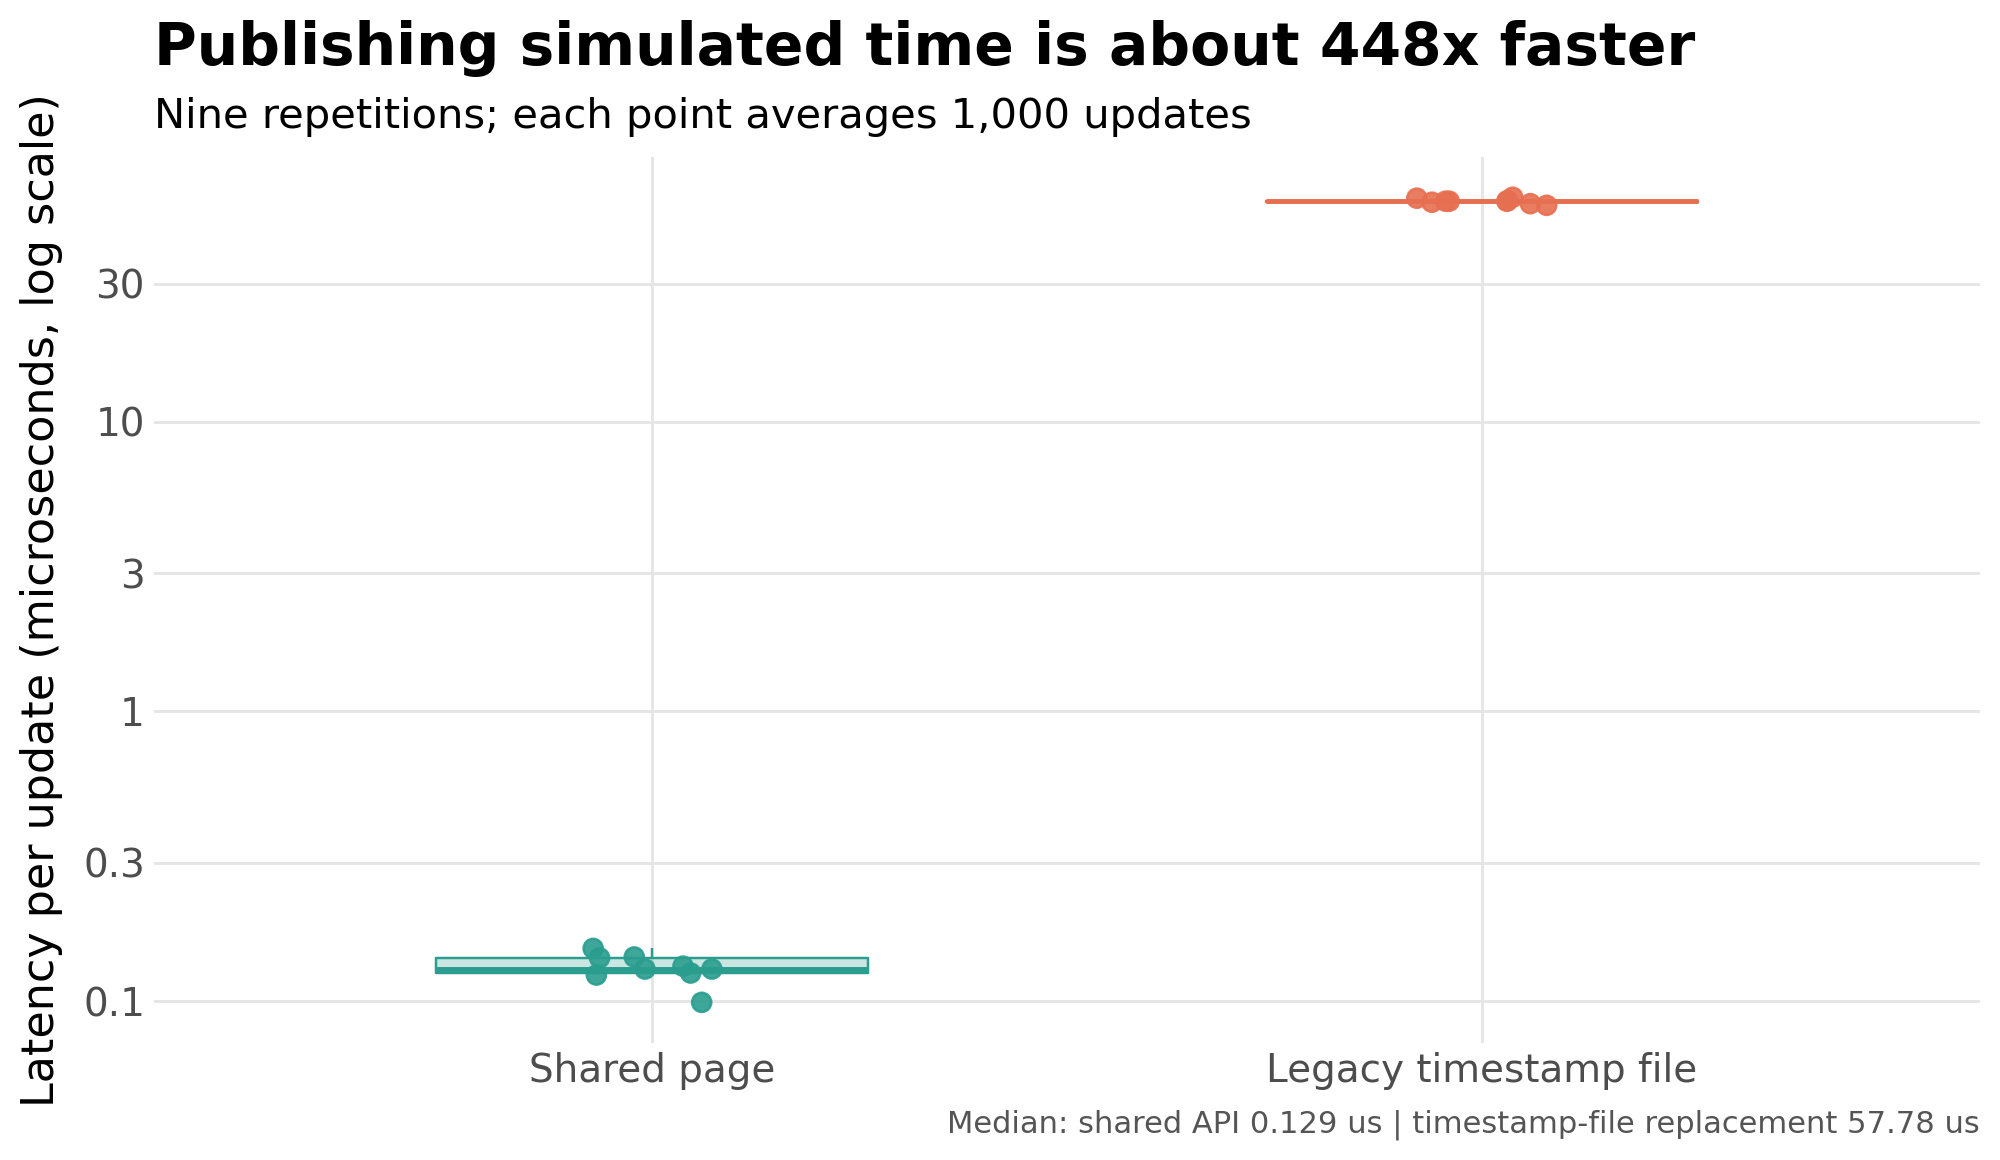

In [5]:
update_plot = micro[micro["mode"].isin(["legacy", "shared"])].copy()
update_plot["clock"] = update_plot["mode"].map(micro_labels)
update_plot["update_us"] = update_plot["update_ns"] / 1_000
update_order = ["Shared page", "Legacy timestamp file"]
update_plot["clock"] = pd.Categorical(
    update_plot["clock"], categories=update_order, ordered=True
)
update_colors = {label: COLORS[label] for label in update_order}

p_update = (
    ggplot(update_plot, aes("clock", "update_us", color="clock"))
    + geom_boxplot(
        aes(fill="clock"), width=0.52, alpha=0.25, outlier_alpha=0
    )
    + geom_jitter(width=0.08, height=0, size=3.4, alpha=0.9)
    + scale_color_manual(values=update_colors)
    + scale_fill_manual(values=update_colors)
    + scale_y_log10(
        breaks=[0.1, 0.3, 1, 3, 10, 30, 100],
        labels=lambda values: [f"{value:g}" for value in values],
    )
    + labs(
        title="Publishing simulated time is about 448x faster",
        subtitle="Nine repetitions; each point averages 1,000 updates",
        x="",
        y="Latency per update (microseconds, log scale)",
        caption=(
            "Median: shared API 0.129 us | "
            "timestamp-file replacement 57.78 us"
        ),
    )
    + large_theme()
    + theme(legend_position="none")
)
p_update

### Microbenchmark interpretation

- Shared reads are **429.54x faster** than legacy reads and only
  **2.23x native**.
- Shared updates are about **448x faster** than atomic timestamp-file
  replacement.
- An archived mmap experiment measured 1,064 ns/read, about 20x slower
  than the final design, because it still entered the complete legacy path
  and remapped control state on updates.
- A marked `strace` region around 10,000 optimized reads contains no
  `open`, `read`, `stat`, `access`, or path lookup.

These numbers isolate clock mechanics. They do not imply a 429x
application speedup; scheduler, tracing, Python, and Flux work remains.

## 4. Why the first end-to-end smoke test looked worse

Before the DFTracer workload was available, a 10-job smoke test compared
shared and legacy modes in a container without the `dftracer` Python
package. Shared looked 27.5% slower. That test showed the integration
worked, but startup dominated and there were too few intercepted reads for
the optimized hot path to matter.

In [6]:
smoke_summary = (
    smoke.groupby("mode")["wall_seconds"]
    .agg(n="size", median_s="median", min_s="min", max_s="max")
    .reindex(["legacy", "shared"])
    .reset_index()
)
smoke_summary["mode"] = smoke_summary["mode"].map({
    "legacy": "Fork legacy", "shared": "Shared page"
})
display(smoke_summary.round(3))
print(
    "This smoke result motivated, rather than replaced, "
    "the annotation-heavy validation below."
)

,mode,n,median_s,min_s,max_s
0,Fork legacy,3,14.529,13.631,16.438
1,Shared page,3,18.530,18.474,19.136


This smoke result motivated, rather than replaced, the annotation-heavy validation below.


## 5. Full rabbit300 Fluxion/DFTracer benchmark

### Workload and controls

- 300 jobs and a 1,153-node Tuolumne resource graph.
- Fluxion at `DFTRACER_ANNOTATION_LEVEL=5`, producing
  **2,570,814** Fluxion events per successful run.
- Same container, Flux stack, Flux Fiction checkout, input trace, broker
  logging, and node-local trace scratch within each phase.
- `NO_FAKE_STAT=1` in all faked-clock arms, because faking build-file
  mtimes makes the editable Meson/Ninja install regenerate indefinitely
  under shared time.
- Timing from `status.json`, excluding image loading and prewarm.
- Every retained row completed all 300 jobs.

Phase 1 alternated fork-legacy and shared order on
`tuolumne1025`. Phase 2 used `tuolumne1009` for the distro,
no-faketime, and level-0 controls. Comparisons across phases therefore
have a node-to-node caveat; the primary 1.95x fork-legacy/shared result
is a controlled same-node comparison.

In [7]:
clock_names = {
    "legacy": "Fork legacy",
    "shared": "Shared page",
    "stock": "Distro legacy",
    "nofaketime": "No libfaketime",
}

def summarize_modes(frame, order):
    rows = []
    for mode in order:
        values = frame.loc[
            frame["mode"] == mode, "sim_seconds"
        ].astype(float).tolist()
        rows.append({
            "clock": clock_names[mode],
            "n": len(values),
            "median_s": np.median(values),
            "min_s": min(values),
            "max_s": max(values),
            "runs_s": ", ".join(f"{value:g}" for value in values),
        })
    return pd.DataFrame(rows)

l5 = full[
    (full["level"] == 5) & (full["disable_io"] == 0)
].copy()
l5_order = ["nofaketime", "shared", "legacy", "stock"]
l5_summary = summarize_modes(l5, l5_order)
shared_median = l5_summary.loc[
    l5_summary["clock"] == "Shared page", "median_s"
].iloc[0]
l5_summary["runtime_vs_shared"] = (
    l5_summary["median_s"] / shared_median
)

l0 = full[full["level"] == 0].copy()
l0_order = ["legacy", "shared", "nofaketime"]
l0_summary = summarize_modes(l0, l0_order)

print("Level 5, normal DFTracer I/O")
display(l5_summary.round({
    "median_s": 1, "min_s": 1, "max_s": 1,
    "runtime_vs_shared": 2,
}))
print("Level 0, Fluxion annotations compiled out")
display(l0_summary.round(1))

Level 5, normal DFTracer I/O


,clock,n,median_s,min_s,max_s,runs_s,runtime_vs_shared
0,No libfaketime,3,43.0,42.0,43.0,"42, 43, 43",1.06
1,Shared page,4,40.5,39.0,42.0,"39, 40, 42, 41",1.00
2,Fork legacy,5,79.0,77.0,82.0,"79, 82, 80, 77, 79",1.95
3,Distro legacy,2,132.0,120.0,144.0,"144, 120",3.26


Level 0, Fluxion annotations compiled out


,clock,n,median_s,min_s,max_s,runs_s
0,Fork legacy,3,37.0,36.0,39.0,"39, 36, 37"
1,Shared page,3,39.0,38.0,39.0,"39, 38, 39"
2,No libfaketime,3,40.0,40.0,41.0,"40, 41, 40"


### Annotation-heavy runtime

Small points are individual successful runs; diamonds are medians. The
no-faketime baseline remains fast because Flux Fiction advances logical
simulation without sleeping, but Fluxion timestamps then use wall time.

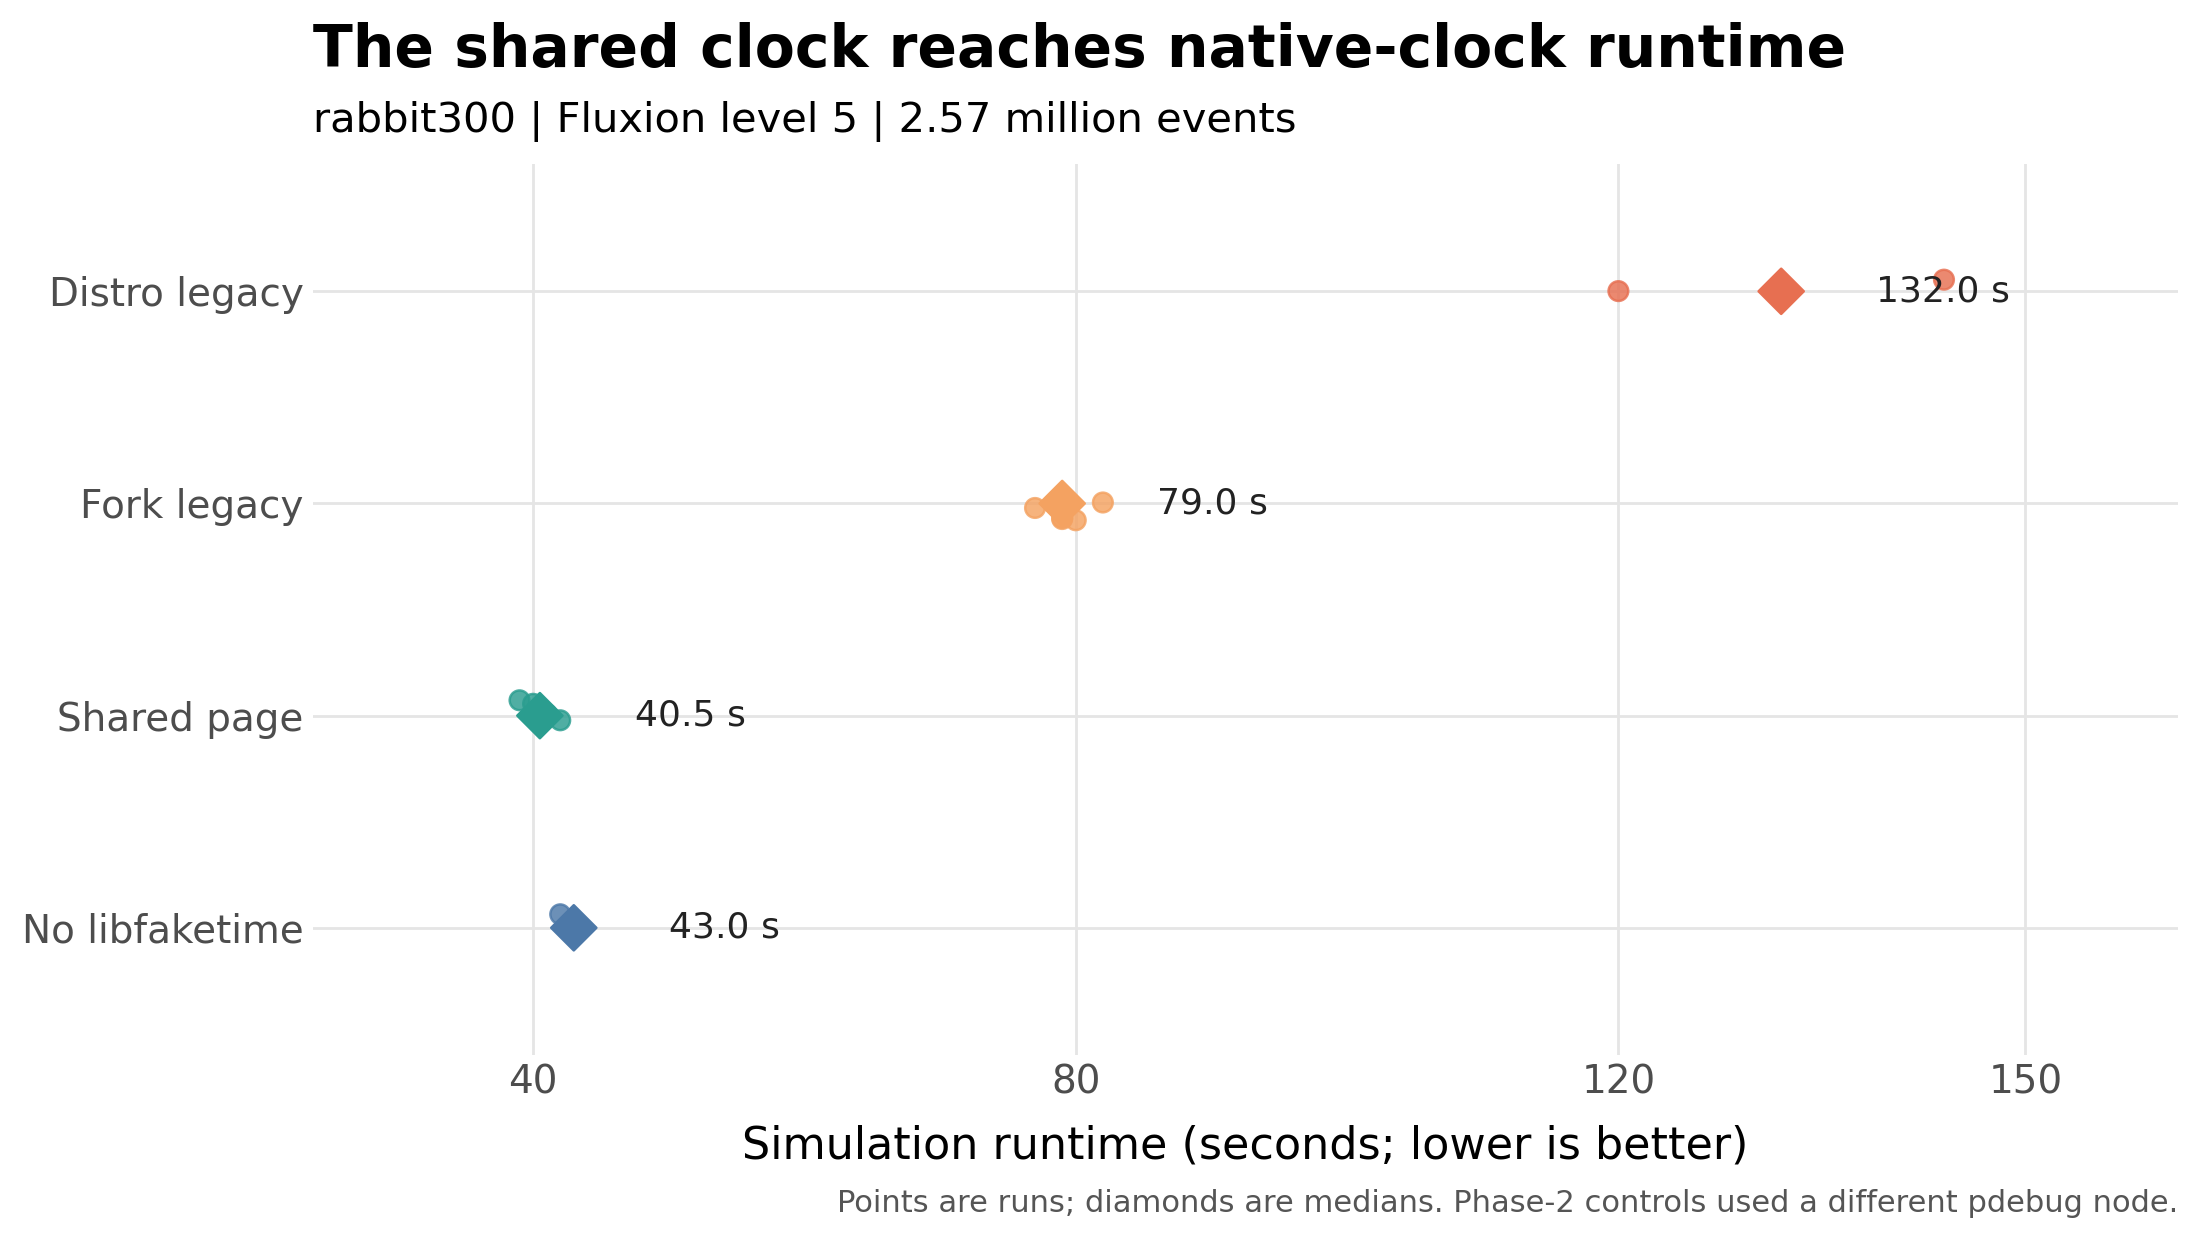

In [8]:
l5_plot = l5.copy()
l5_plot["clock"] = l5_plot["mode"].map(clock_names)
l5_labels = [clock_names[mode] for mode in l5_order]
l5_plot["clock"] = pd.Categorical(
    l5_plot["clock"], categories=l5_labels, ordered=True
)
l5_medians = l5_summary[["clock", "median_s"]].copy()
l5_medians["clock"] = pd.Categorical(
    l5_medians["clock"], categories=l5_labels, ordered=True
)
l5_medians["label"] = l5_medians["median_s"].map(
    lambda value: f"{value:.1f} s"
)
l5_colors = {label: COLORS[label] for label in l5_labels}

p_l5 = (
    ggplot(l5_plot, aes("sim_seconds", "clock", color="clock"))
    + geom_jitter(width=0, height=0.08, size=3.5, alpha=0.82)
    + geom_point(
        l5_medians,
        aes("median_s", "clock", color="clock"),
        inherit_aes=False,
        shape="D",
        size=6,
    )
    + geom_text(
        l5_medians,
        aes("median_s", "clock", label="label"),
        inherit_aes=False,
        nudge_x=7,
        size=13,
        color="#222222",
        ha="left",
    )
    + scale_color_manual(values=l5_colors)
    + scale_x_continuous(
        limits=(30, 155), breaks=[40, 80, 120, 150]
    )
    + labs(
        title="The shared clock reaches native-clock runtime",
        subtitle=(
            "rabbit300 | Fluxion level 5 | 2.57 million events"
        ),
        x="Simulation runtime (seconds; lower is better)",
        y="",
        caption=(
            "Points are runs; diamonds are medians. "
            "Phase-2 controls used a different pdebug node."
        ),
    )
    + large_theme(width=11, height=6.2)
    + theme(legend_position="none")
)
p_l5

### No-annotation control

Fluxion was rebuilt at annotation level 0, and `readelf` confirmed
that its modules have no `libdftracer_core` dependency. Mode order
rotated across repetitions.

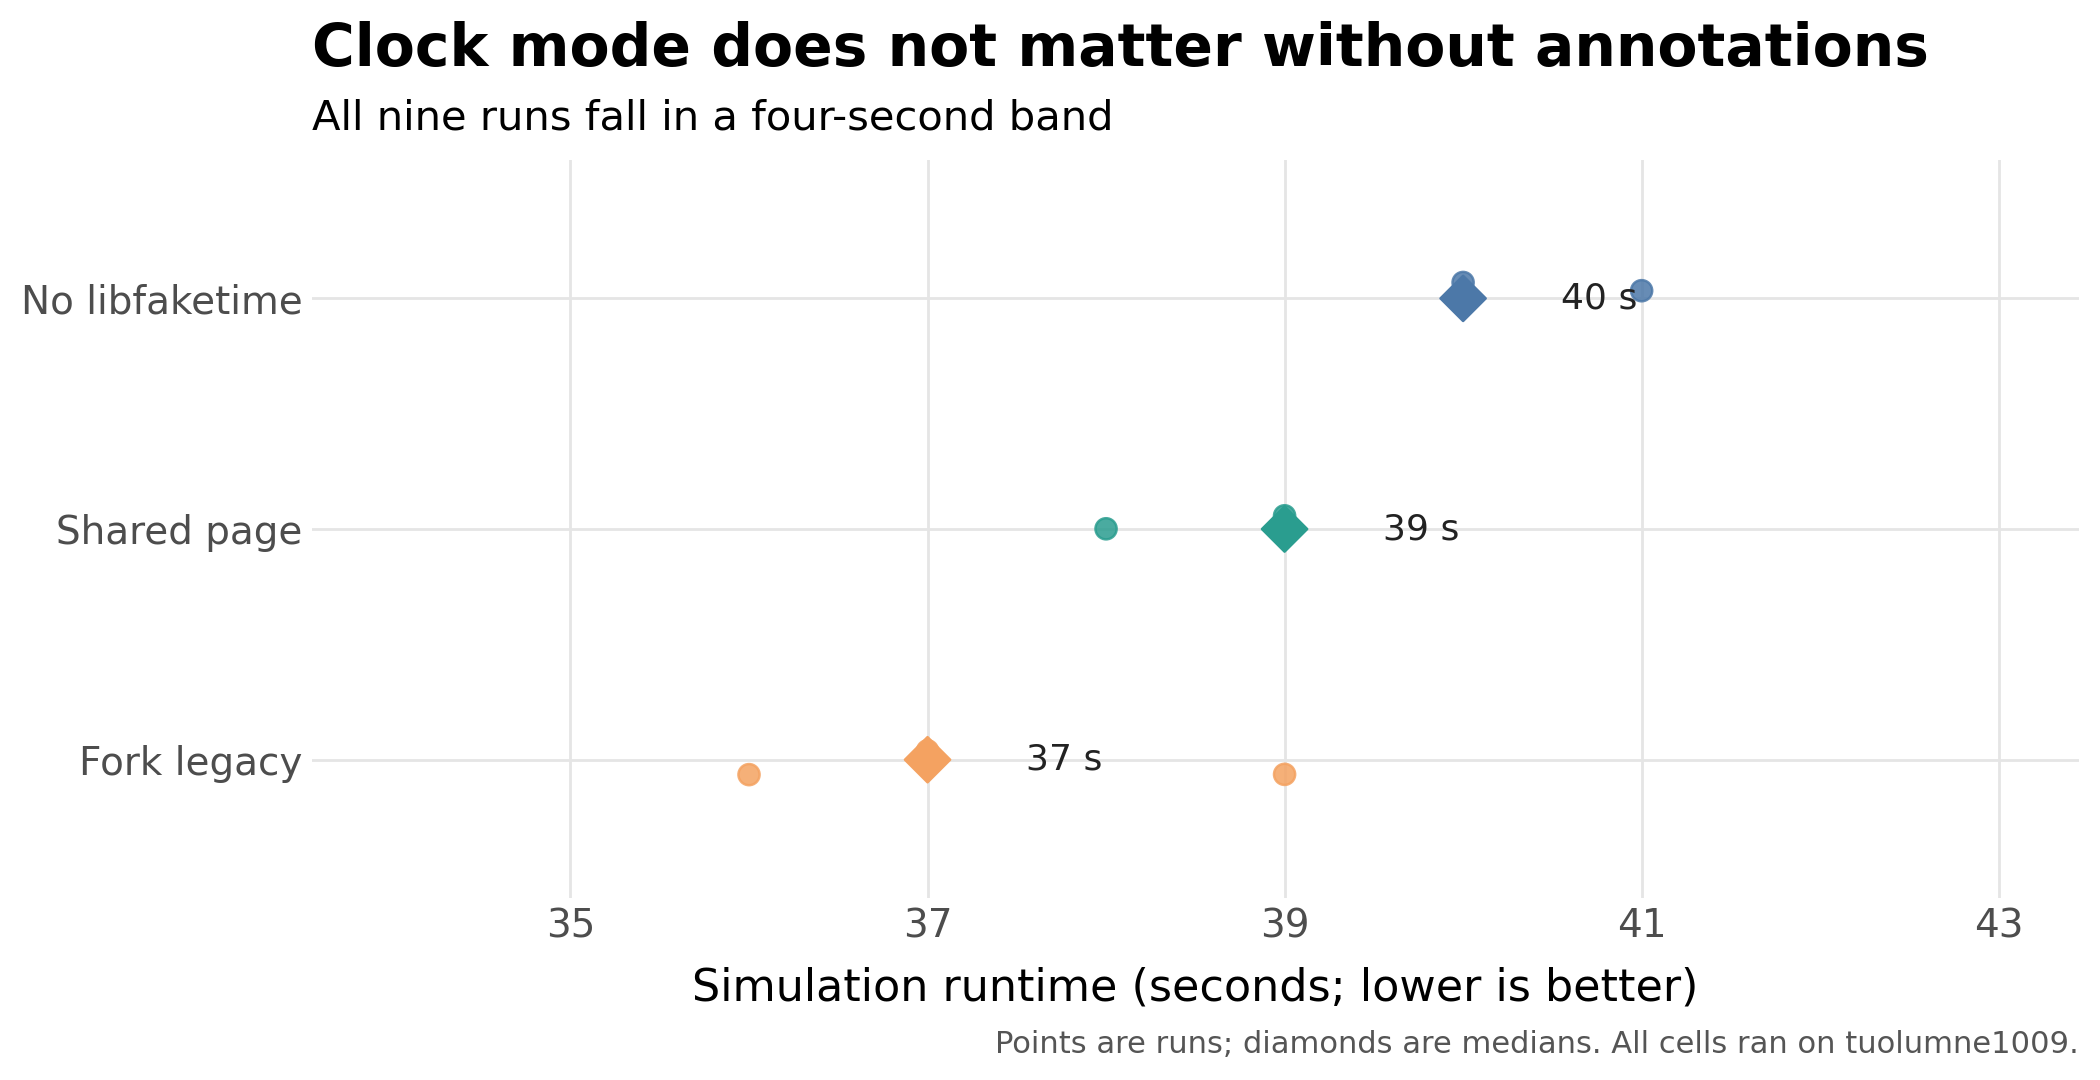

In [9]:
l0_plot = l0.copy()
l0_plot["clock"] = l0_plot["mode"].map(clock_names)
l0_labels = [clock_names[mode] for mode in l0_order]
l0_plot["clock"] = pd.Categorical(
    l0_plot["clock"], categories=l0_labels, ordered=True
)
l0_medians = l0_summary[["clock", "median_s"]].copy()
l0_medians["clock"] = pd.Categorical(
    l0_medians["clock"], categories=l0_labels, ordered=True
)
l0_medians["label"] = l0_medians["median_s"].map(
    lambda value: f"{value:.0f} s"
)
l0_colors = {label: COLORS[label] for label in l0_labels}

p_l0 = (
    ggplot(l0_plot, aes("sim_seconds", "clock", color="clock"))
    + geom_jitter(width=0, height=0.07, size=3.8, alpha=0.85)
    + geom_point(
        l0_medians,
        aes("median_s", "clock", color="clock"),
        inherit_aes=False,
        shape="D",
        size=6,
    )
    + geom_text(
        l0_medians,
        aes("median_s", "clock", label="label"),
        inherit_aes=False,
        nudge_x=0.55,
        size=13,
        color="#222222",
        ha="left",
    )
    + scale_color_manual(values=l0_colors)
    + scale_x_continuous(
        limits=(34, 43), breaks=[35, 37, 39, 41, 43]
    )
    + labs(
        title="Clock mode does not matter without annotations",
        subtitle="All nine runs fall in a four-second band",
        x="Simulation runtime (seconds; lower is better)",
        y="",
        caption=(
            "Points are runs; diamonds are medians. "
            "All cells ran on tuolumne1009."
        ),
    )
    + large_theme(width=10.5, height=5.4)
    + theme(legend_position="none")
)
p_l0

### What the full benchmark says

1. **The controlled result is 1.95x.** Fork-legacy and shared ran on the
   same node with the same modified library; only clock mode changed.
   Median runtime fell from 79.0 to 40.5 s.
2. **Shared is at the native-clock floor.** No-faketime measured 42, 43,
   and 43 s. Shared measured 39-42 s with normal DFTracer I/O.
3. **The fork improves legacy mode too.** Distro legacy was 120 and 144 s
   with normal I/O, versus a 79 s fork-legacy median and 40.5 s shared
   median. This supporting comparison crosses pdebug nodes and has only
   two distro repetitions.
4. **Annotations become nearly free at whole-run scale.** Shared level 5
   is 40.5 s versus 39 s at level 0; no-faketime is 43 versus 40 s.
5. **A distro-specific anomaly remains.** With
   `DFTRACER_DISABLE_IO=1`, distro runs slowed to 218 and 287 s.
   Reversing cell order reproduced the effect, but not its cause.

## 6. Correctness: faster must still mean the same clock

A fast trace is useless if it drops annotations or moves Fluxion off
simulated time. Representative traces were streamed and checked
independently of the timing summary.

In [10]:
trace_validation = pd.DataFrame([
    (
        "Fork legacy", "20260729_124309_L5-legacy-io0-r3",
        2_570_814, 1_260, 1_577_836_770.460, 391.609, "simulated",
    ),
    (
        "Shared page", "20260729_124516_L5-shared-io0-r3",
        2_570_814, 1_260, 1_577_836_770.432, 391.539, "simulated",
    ),
    (
        "Distro legacy", "20260729_132413_L5-stock-io1-r1",
        2_570_814, 1_260, 1_577_836_772.442, 392.023, "simulated",
    ),
    (
        "No libfaketime", "20260729_133900_L5-nofaketime-io1-r1",
        2_570_814, 900, 1_785_357_543.872, 37.618, "real wall time",
    ),
], columns=[
    "clock", "representative_run", "fluxion_events",
    "simulation_events", "fluxion_epoch_s", "fluxion_span_s",
    "Fluxion timestamp domain",
])
display(trace_validation)

level0_hashes = []
for run_dir in full.loc[full["level"] == 0, "run_dir"]:
    path = (
        UT / "ab-faketime/runs" / run_dir
        / "output/resource_usage_timeseries.csv"
    )
    level0_hashes.append(
        hashlib.sha256(path.read_bytes()).hexdigest()
    )

assert trace_validation["fluxion_events"].nunique() == 1
assert len(set(level0_hashes)) == 1
assert (full["jobs"] == 300).all()
print(
    "All representative level-5 traces: "
    f"{trace_validation.fluxion_events.iloc[0]:,} Fluxion events"
)
print(f"All nine level-0 resource-usage files: {level0_hashes[0]}")
print("Every retained benchmark run completed 300/300 jobs.")

,clock,representative_run,fluxion_events,simulation_events,fluxion_epoch_s,fluxion_span_s,Fluxion timestamp domain
0,Fork legacy,20260729_124309_L5-legacy-io0-r3,2570814,1260,1.577837e+09,391.609,simulated
1,Shared page,20260729_124516_L5-shared-io0-r3,2570814,1260,1.577837e+09,391.539,simulated
2,Distro legacy,20260729_132413_L5-stock-io1-r1,2570814,1260,1.577837e+09,392.023,simulated
3,No libfaketime,20260729_133900_L5-nofaketime-io1-r1,2570814,900,1.785358e+09,37.618,real wall time


All representative level-5 traces: 2,570,814 Fluxion events
All nine level-0 resource-usage files: 5991d61ab978e28188450947a1ab11db2e9bff2818d2cfd25be5a374ed1c95a9
Every retained benchmark run completed 300/300 jobs.


The faked-clock modes contain the same 2,570,814 Fluxion events in the
same 2020 epoch. Shared therefore propagates through the broker, modules,
forks, and execs correctly. No-faketime preserves the event count, but its
Fluxion events are stamped in real 2026 wall time while explicit simulation
events stay in 2020. It is a performance floor, not a valid unified-trace
mode. Its simulation-event count is 900 because it has no 360
`faketime_advance` events.

All nine level-0 runs end at the same simulated time and have
byte-identical resource-usage series. Their traces contain no Fluxion
`CPP_APP` events. Flux Fiction's Python-side simulation tracing
remains enabled, so level 0 means no Fluxion annotations, not removal of
the dftracer package.

## 7. Conclusions and open questions

The measurements line up across scales:

- The C benchmark identifies the mechanism: timestamp-file reads cost
  about 22.7 microseconds; the shared read costs 52.9 nanoseconds.
- The annotation workload shows the application effect: eliminating
  millions of file-backed reads nearly halves total runtime.
- The no-faketime and level-0 controls locate the floor: shared mode is
  already there without sacrificing the simulated timeline.
- The tiny smoke test is reconciled rather than hidden: with almost no
  hot-path reads, startup noise dominates.

Caveats and follow-up work:

1. Repeat all four level-5 arms in one randomized matrix on one node before
   treating the distro ratio as publication-grade.
2. Investigate why shared mode requires `NO_FAKE_STAT=1` with the
   editable Meson install; realtime and file-mtime offsets may not be fully
   consistent after updates.
3. Investigate the distro-specific
   `DFTRACER_DISABLE_IO=1` inversion.
4. Stress abnormal termination and stale
   `/dev/shm/faketime_clock_*` cleanup in long campaigns.

**The lock-free shared page removes the libfaketime bottleneck and makes
a fully annotated, correctly simulated Fluxion trace run at essentially
native-clock speed.**

## 8. Reproduction commands

### Microbenchmark

```bash
cd /g/g14/ashworth12/workspace/ff-podman/libfaketime-shared-clock
CC=/usr/bin/gcc CALLS=1000000 REPETITIONS=9 UPDATE_CALLS=1000 \
  benchmarks/shared-clock/run_benchmark.sh
benchmarks/shared-clock/verify_no_hotpath_files.sh
```

### Full benchmark

Run these through `flux proxy ALLOCATION flux run -N1 ...` on an
allocated node:

```bash
cd /g/g14/ashworth12/workspace/ff-podman/unified-trace

# Fork legacy/shared level-5 matrix.
bash scripts/ab_run.sh

# Distro library with reversed I/O-setting order.
REPS=1 REP_START=1 bash scripts/ab_stock_arm.sh
REPS=1 REP_START=2 bash scripts/ab_stock_arm.sh

# Native-clock level-5 control.
REPS=3 SKIP_L5_BUILD=1 SKIP_L0=1 \
  LEVEL5_MODES=nofaketime LEVEL5_NOIO_VALUES=0 \
  bash scripts/ab_faketime.sh

# Build level 0 and rotate legacy/shared/nofaketime.
REPS=3 bash scripts/ab_level0_run.sh
```

Primary artifacts:

- `libfaketime-shared-clock/benchmarks/shared-clock/benchmark_report.md`
- `libfaketime-shared-clock/benchmarks/shared-clock/raw_results.csv`
- `unified-trace/ab-faketime/report.md`
- `unified-trace/ab-faketime/results_ok.csv`